## 타겟 라벨링

In [49]:
# 타겟 라벨링

In [40]:
# L.RD, L.Vac, R.RD, R.Vac : 타겟
# 그 외 : 피쳐 

In [1]:
# 한글, 음수 시각화 설정

#시각화 패키지
import matplotlib.pyplot as plt

#시각화에서 한글을 사용하기 위한 설정
import platform
from matplotlib import font_manager, rc

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
    
#윈도우의 경우
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
    rc('font', family=font_name)
    
#시각화에서 음수를 표현하기 위한 설정
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False 

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN


In [33]:
feat_extraction_df = pd.read_csv('../data/feature_extraction_df.csv', index_col= 0)
feat_extraction_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8143 entries, 2016-01-01 07:00:00 to 2016-12-31 23:00:00
Columns: 124 entries, X1WOS45106_PV to L.Vac
dtypes: float64(121), int64(3)
memory usage: 7.8+ MB


In [34]:
# 모델링 결과 : 공정명에 폐기가 포함된 열(직접적인 관련있어 보이는 열로 공정명이 아니어보이므로 삭제)
# 폐기를 포함해서 로지스틱 회귀 수행하면 99%의 정확도 등의 평가지표
# 삭제 후 68.8%정도도
# 또한, L.RD에서 관련성이 높은거보면 폐기율과 관련있는 타겟은 RD가 아닌가싶음

feat_extraction_df.iloc[:, -15:]

# immediate_connection_cols = feat_extraction_df.iloc[:, -11:-7].columns.tolist()
# immediate_connection_cols # 4개

# feat_extraction_df = feat_extraction_df.drop(immediate_connection_cols, axis= 1)
# feat_extraction_df.info() # (8143, 120)

,S_AB9_AB10_U_L,S_AB10_AB11_L_L,S_C1_C2_L_L,S_C2_C3_L_L,투입.LEFT.,ROLLDOWN.폐기.LEFT.,진공패드.폐기.LEFT.,폐기율...,bgm_predict_proba_0,bgm_predict_proba_1,bgm_predict_proba_2,bgm_predict_proba_3,bgm_predict_proba_4,L.RD,L.Vac
dat...date.name.,,,,,,,,,,,,,,,
2016-01-01 07:00:00,-0.398517,-1.277785,-0.195736,0.491620,80,2,5,11.69,1.917320e-245,1.000000e+00,3.313288e-25,9.206467e-64,6.415762e-146,0.025,0.063
2016-01-01 08:00:00,-0.367705,-1.201661,-0.500742,0.587871,92,0,2,7.19,2.428243e-180,9.999586e-01,4.142946e-05,1.177309e-62,3.785367e-133,0.000,0.022
2016-01-01 09:00:00,-0.393200,-1.165167,-0.164556,0.397216,64,1,4,3.85,1.004757e-196,9.876965e-01,1.230354e-02,3.392099e-73,2.458107e-156,0.016,0.063
2016-01-01 10:00:00,-0.314390,-1.095003,-0.824056,0.878934,68,0,7,4.96,1.574613e-207,9.797669e-01,2.023306e-02,1.972134e-69,2.990744e-153,0.000,0.103
2016-01-01 11:00:00,-0.359464,-1.009744,-0.504655,0.795806,36,0,0,0.00,2.143381e-223,9.086279e-01,9.137210e-02,4.796377e-78,2.608765e-172,0.000,0.000
2016-01-01 12:00:00,-0.357450,-0.885234,0.192290,0.310730,79,2,1,3.13,2.393893e-225,6.824822e-01,3.175178e-01,1.111068e-82,9.491280e-176,0.025,0.013
2016-01-01 13:00:00,-0.408138,-0.836180,0.198596,0.365394,89,0,4,2.34,9.120469e-171,6.943040e-05,9.999306e-01,2.604024e-71,2.865929e-146,0.000,0.045
2016-01-01 14:00:00,-0.439552,-0.992929,0.962061,-0.193725,85,3,6,4.97,1.902221e-135,9.990045e-01,9.954640e-04,2.055978e-44,8.091708e-137,0.035,0.071
2016-01-01 15:00:00,-0.424497,-0.835854,0.047712,0.411257,63,4,4,5.59,5.483582e-130,1.346410e-05,9.999865e-01,6.247085e-53,2.445012e-130,0.063,0.063


## 타겟 불량 라벨링(DBSCAN)

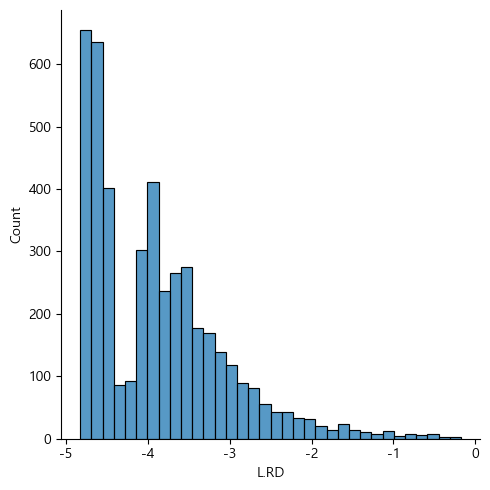

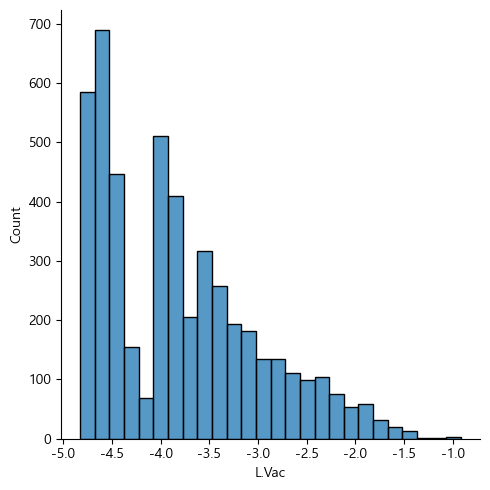

In [12]:
sns.displot(np.log(feat_extraction_df['L.RD']))
sns.displot(np.log(feat_extraction_df['L.Vac']))

In [15]:
# 타겟 간 상관계수

corr_target = feat_extraction_df['L.RD'].corr(feat_extraction_df['L.Vac'])
print("L.RD와 L.VAC 간의 상관계수:", corr_target)

# 0.2정도로 별도로 훈련

L.RD와 L.VAC 간의 상관계수: 0.19508106124792296


In [ ]:
# 이상치에 대한 임계값을 모르므로 DBSCAN활용
# eps : 너무 크면 하나의 클러스터로 묶일 수 있고 너무 작으면 클러스터가 너무 세분화됨

In [16]:
target_df = feat_extraction_df[['L.RD', 'L.Vac']]

In [17]:
# print(target_df['L.RD'].isnull().sum())

In [18]:
RD_threshold = np.percentile(feat_extraction_df['L.RD'], q= 87)
target_df['target_RD_defect'] = np.where(feat_extraction_df['L.RD'] >= RD_threshold, 1, 0)
target_df['target_RD_defect'].value_counts() # 7326, 1079

target_RD_defect
0    7064
1    1079
Name: count, dtype: int64

In [19]:
# 폐기율 데이터 (연속형 타겟)
target_RD = feat_extraction_df['L.RD'].values.reshape(-1, 1)  # 1차원 데이터를 2D 형태로 변환

# DBSCAN 적용
dbscan = DBSCAN(eps=0.008, min_samples= 1500) # 0.008보다 크면 오히려 이상치 줄어들고 0.007로 하면 클러스터가 늘어남
clusters = dbscan.fit_predict(target_RD)

np.unique(clusters)

# 결과를 데이터프레임에 추가
target_df = pd.DataFrame()
target_df['RD_cluster'] = clusters
print(target_df['RD_cluster'].value_counts())  # 각 클러스터별 데이터 수

RD_cluster
 0    7096
-1    1047
Name: count, dtype: int64


In [20]:
RD_outlier_idx = target_df[target_df['RD_cluster'] == -1].index
RD_outlier_values = feat_extraction_df.iloc[RD_outlier_idx]['L.RD'].values

print(np.max(RD_outlier_values))
print(np.min(RD_outlier_values)) # 이상치 중 가장 작은 값보다 크면 불량(폐기율이기 때문)

target_df['target_RD_defect'] = np.where(feat_extraction_df['L.RD'] >= np.min(RD_outlier_values), 1, 0)
target_df[['target_RD_defect']].value_counts()

0.841
0.034


target_RD_defect
0                   7096
1                   1047
Name: count, dtype: int64

In [21]:
# 폐기율 데이터 (연속형 타겟)
target_Vac = feat_extraction_df['L.Vac'].values.reshape(-1, 1)  # 1차원 데이터를 2D 형태로 변환

# DBSCAN 적용
dbscan = DBSCAN(eps= 0.008, min_samples= 1000) 
clusters = dbscan.fit_predict(target_Vac)

# 결과를 데이터프레임에 추가
target_df = pd.DataFrame()
target_df['Vac_cluster'] = clusters
print(target_df['Vac_cluster'].value_counts())  # 각 클러스터별 데이터 수


Vac_cluster
 0    7039
-1    1104
Name: count, dtype: int64


In [22]:
Vac_outlier_idx = target_df[target_df['Vac_cluster'] == -1].index
Vac_outlier_values = feat_extraction_df.iloc[Vac_outlier_idx]['L.Vac'].values

print(np.max(Vac_outlier_values))
print(np.min(Vac_outlier_values))

target_df['target_Vac_defect'] = np.where(feat_extraction_df['L.Vac'] >= np.min(Vac_outlier_values), 1, 0)
target_df[['target_Vac_defect']].value_counts()

0.4
0.039


target_Vac_defect
0                    7039
1                    1104
Name: count, dtype: int64

In [23]:
# preprocessing_df.info()
feat_extraction_df['RD_defect'] = np.where(feat_extraction_df['L.RD'] >= np.min(RD_outlier_values), 1, 0) # 1047개의 불량
feat_extraction_df['Vac_defect'] = np.where(feat_extraction_df['L.Vac'] >= np.min(Vac_outlier_values), 1, 0) # 1104개의 불량
# preprocessing_df.info()

analysis_df = feat_extraction_df.drop(['L.RD', 'L.Vac'], axis= 1)
RD_analysis_df = analysis_df.drop(['Vac_defect'], axis= 1)
Vac_analysis_df = analysis_df.drop(['RD_defect'], axis= 1)

RD_analysis_df.info() # (8143, 123)

<class 'pandas.core.frame.DataFrame'>
Index: 8143 entries, 2016-01-01 07:00:00 to 2016-12-31 23:00:00
Columns: 115 entries, X1WOS45106_PV to RD_defect
dtypes: float64(114), int32(1)
memory usage: 7.2+ MB


In [24]:
RD_total_df = RD_analysis_df.copy()
RD_total_df.to_csv('../data/RD_total_df.csv', header= True, index= True)

Vac_total_df = Vac_analysis_df.copy()
Vac_total_df.to_csv('../data/Vac_total_df.csv', header= True, index= True)

## - 스케일링된 DF로 타겟 불량 라벨링(DBSCAN)

In [25]:
scaled_analysis_df = feat_extraction_df.drop(['L.RD', 'L.Vac'], axis= 1)
scaled_RD_analysis_df = scaled_analysis_df.drop(['Vac_defect'], axis= 1)
scaled_Vac_analysis_df = scaled_analysis_df.drop(['RD_defect'], axis= 1)

scaled_RD_analysis_df.info() # (8143, 123)

scaled_RD_total_df = scaled_RD_analysis_df.copy()
scaled_RD_total_df.to_csv('../data/scaled_RD_total_df.csv', header= True, index= True)

scaled_Vac_total_df = scaled_Vac_analysis_df.copy()
scaled_Vac_total_df.to_csv('../data/scaled_Vac_total_df.csv', header= True, index= True)

<class 'pandas.core.frame.DataFrame'>
Index: 8143 entries, 2016-01-01 07:00:00 to 2016-12-31 23:00:00
Columns: 115 entries, X1WOS45106_PV to RD_defect
dtypes: float64(114), int32(1)
memory usage: 7.2+ MB


## 4. 타겟 2000개 샘플링(양품 : 1000개, 불량품 : 1000개) 

In [26]:
RD_analysis_df['RD_defect'].value_counts()[1]

1047

In [27]:
RD_normal_df = RD_analysis_df[RD_analysis_df['RD_defect'] == 0]
RD_defective_df = RD_analysis_df[RD_analysis_df['RD_defect'] == 1]
RD_normal_sample_df = RD_normal_df.sample(n= RD_analysis_df['RD_defect'].value_counts()[1], random_state= 42)
RD_sample_df = pd.concat([RD_normal_sample_df, RD_defective_df])
RD_sample_df.info()

RD_sample_df.to_csv('../data/RD_sample_df.csv', header= True, index= True) # (2094, 123)

<class 'pandas.core.frame.DataFrame'>
Index: 2094 entries, 2016-02-22 23:00:00 to 2016-12-31 01:00:00
Columns: 115 entries, X1WOS45106_PV to RD_defect
dtypes: float64(114), int32(1)
memory usage: 1.8+ MB


In [28]:
Vac_normal_df = Vac_analysis_df[Vac_analysis_df['Vac_defect'] == 0]
Vac_defective_df = Vac_analysis_df[Vac_analysis_df['Vac_defect'] == 1]
Vac_normal_sample_df = Vac_normal_df.sample(n= Vac_analysis_df['Vac_defect'].value_counts()[1], random_state= 42)
Vac_sample_df = pd.concat([Vac_normal_sample_df, Vac_defective_df])
Vac_sample_df.info()

Vac_sample_df.to_csv('../data/Vac_sample_df.csv', header= True, index= True)

<class 'pandas.core.frame.DataFrame'>
Index: 2208 entries, 2016-04-13 18:00:00 to 2016-12-30 06:00:00
Columns: 115 entries, X1WOS45106_PV to Vac_defect
dtypes: float64(114), int32(1)
memory usage: 1.9+ MB


In [29]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

RD_sample_df.describe()

,X1WOS45106_PV,X1WOS45109_PV,DB.N2.SCREEN.FLOW.LEFT.1FI49011_PV,N2.TO.EA1313A.1FI33503A_PV,ROOF.HEATING.Zone.1.1JIC31101.PV,ROOF.HEATING.Zone.2.1JIC31102.PV,ROOF.HEATING.Zone.4.1JIC31104.PV,ATM.FLOW.SECT.9.N2.1FIC33415.PV,Gross.width,UPPER.AB1.Z1.TMP.1TIC41101.PV,UPPER.AB8.Z99.TMP.1TIC41801.PV,LIFT.OUT.ROL.MTR.M1.CUR.1WII40101.PV,LEHR.DRV.MTR..M4.1.CUR.1WII40104.PV,LEHR.DRV.MTR..M5.1.CUR.1WII40106.PV,LEHR.DRV.MTR..M7.1.CUR.1WII40110.PV,LEHR.DRV.MTR..M7.2.CUR.1WII40111.PV,LEHR.DRV.MTR..M8.1.CUR.1WII40112.PV,LEHR.DRV.MTR..M12.1.CUR.1WII40120.PV,LEHR.DRV.MTR..M13.1.CUR.1WII40122.PV,LEHR.DRV.MTR..M15.1.CUR.1WII40126.PV,LEHR.DRV.MTR..M16.1.CUR.1WII40128.PV,LEHR.DRV.MTR..M16.2.CUR.1WII40129.PV,LEHR.DRV.MTR..M17.1.CUR.1WII40130.PV,LEHR.DRV.MTR..M18.1.CUR.1WII40132.PV,LEHR.DRV.MTR..M18.2.CUR.1WII40133.PV,X1WOS45106_PV.1,DCS_Offset_RPM_M11.1WOS45111_PV.1,TMP.GLASS..BAY.1.1TI30101.PV,X.1.BAY.LEFT.PRESSURE.1CLBAY1LEFT_CPV,X.7.BAY.RIGHT.PRESSURE.1CLBAY7RIGHT_CPV,X.1.LEHR.SO2.ANALYZER.1AI44110.PV,X.1.LEHR.O2.ANALYZER.1AI44111.PV,X.2.LEHR.SO2.ANALYZER.1AI44112.PV,X.2.LEHR.O2.ANALYZER.1AI44113.PV,N2.TO.EA1313B.1FI33527A_PV,N2.TO.HOOD.DOWN.STREAM.1FI33505A_PV,N2.TO.HOOD.UP.STREAM.1FI33506A_PV,LEHR.AB1.PRESS.1PI40302.PV,DB.HEAT.BTM.LEFT.1.TMP.1TI40315.PV,DB.BTM.UP.STM.TC.RC.1TI40402_PV,DB.BTM.UP.STM.TC.RE.1TI40403_PV,DB.HEAT.BOTTOM.1.1JIC40308.PV,DB.HEAT.BOTTOM.3.1JIC40310.PV,ROOF.HT.BAY.3.TOTAL.PWR.1CLBAY3_CPV,ROOF.HT.BAY.8.TOTAL.PWR.1CLBAY8_CPV,ROOF.HT.BAY.9.TOTAL.PWR.1CLBAY9_CPV,ROOF.HEATING.Zone.3.1JIC31103.PV.1,ROOF.HEATING.Zone.4.1JIC31104.PV.1,ROOF.HEATING.Zone.5.1JIC31105.PV,ROOF.HEATING.Zone.6.1JIC31106.PV,ROOF.HEATING.Zone12.1JIC31112.PV,ROOF.HEATING.Zone31.1JIC31131.PV,ROOF.HEATING.Zone39.1JIC31139.PV,ROOF.HEATING.Zone45.1JIC31145.PV,ROOF.HEATING.Zone49.1JIC31149.PV,ROOF.HEATING.Zone51.1JIC31151.PV,ROOF.HEATING.Zone53.1JIC31153.PV,ROOF.HEATING.Zone54.1JIC31154.PV,ROOF.HEATING.Zone55.1JIC31155.PV,ROOF.HEATING.Zone60.1JIC31160.PV,ROOF.HEATING.Zone63.1JIC31163.PV,ROOF.HEATING.Zone73.1JIC31173.PV,ROOF.HEATING.Zone77.1JIC31177.PV,ROOF.HEATING.Zone81.1JIC31181.PV,ATM.FLOW.SECT.2.N2.1FI33401.PV,ATM.FLOW.SECT.3.N2.1FI33403.PV,ATM.FLOW.SECT.4.N2.1FI33405.PV,SPOUT.LEFT.TOP.1FI33514.PV,SPOUT.RIGHT.BOTTOM.1FI33518.PV,ATM.N2.H2.5..함유율.1CLFI33402_CPV,ATM.N2.H2.9..함유율.1CLFI33406_CPV,LOR.1.L.Axis,LOR.1.L.Hori,LOR.2.L.Axis,LOR.3.L.Axis,LOR.3.L.Hori,LOR.1.R.Axis,LOR.1.R.Hori,LOR.2.R.Axis,LOR.2.R.Hori,LOR.3.R.Hori,r_tin_bay_5_7,lc_rc_btm_dn,le_re_btm_dn,l_r_top_n.1,top_5,D_AB1_U_LR,D_AB3_U_LR,D_AB5_L_LR,D_AB8_U_LR,D_AB9_U_LR,D_AB10_U_LR,D_AB11_U_LR,D_AB11_L_LR,D_AB2_R_UL,D_AB4_L_UL,D_AB6_R_UL,D_AB8_L_UL,D_C4_U_LR,D_C4_L_LR,D_C1_R_UL,D_C3_L_UL,D_GLS_AB7_LR,D_GLS_F_LR,D_GLS_RET_LR,S_AB1_AB2_U_R,S_AB2_AB3_U_L,S_AB7_AB8_U_L,S_AB8_AB9_U_L,bgm_predict_proba_0,bgm_predict_proba_1,bgm_predict_proba_2,bgm_predict_proba_3,bgm_predict_proba_4,RD_defect
count,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2.094000e+03,2.094000e+03,2094.000000,2.094000e+03,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2.094000e+03,2094.000000,2.094000e+03,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094

## - scaled DF 약 양품 : 1000개, 불량 : 1000개 샘플링

In [30]:
scaled_RD_normal_df = scaled_RD_analysis_df[scaled_RD_analysis_df['RD_defect'] == 0]
scaled_RD_defective_df = scaled_RD_analysis_df[scaled_RD_analysis_df['RD_defect'] == 1]
scaled_RD_normal_sample_df = scaled_RD_normal_df.sample(n= scaled_RD_analysis_df['RD_defect'].value_counts()[1], random_state= 42)
scaled_RD_sample_df = pd.concat([scaled_RD_normal_sample_df, scaled_RD_defective_df])
scaled_RD_sample_df.info()

scaled_RD_sample_df.to_csv('../data/scaled_RD_sample_df.csv', header= True, index= True)
print()

scaled_Vac_normal_df = scaled_Vac_analysis_df[scaled_Vac_analysis_df['Vac_defect'] == 0]
scaled_Vac_defective_df = scaled_Vac_analysis_df[scaled_Vac_analysis_df['Vac_defect'] == 1]
scaled_Vac_normal_sample_df = scaled_Vac_normal_df.sample(n= scaled_Vac_analysis_df['Vac_defect'].value_counts()[1], random_state= 42)
scaled_Vac_sample_df = pd.concat([scaled_Vac_normal_sample_df, scaled_Vac_defective_df])
scaled_Vac_sample_df.info()

scaled_Vac_sample_df.to_csv('../data/scaled_Vac_sample_df.csv', header= True, index= True)

<class 'pandas.core.frame.DataFrame'>
Index: 2094 entries, 2016-02-22 23:00:00 to 2016-12-31 01:00:00
Columns: 115 entries, X1WOS45106_PV to RD_defect
dtypes: float64(114), int32(1)
memory usage: 1.8+ MB

<class 'pandas.core.frame.DataFrame'>
Index: 2208 entries, 2016-04-13 18:00:00 to 2016-12-30 06:00:00
Columns: 115 entries, X1WOS45106_PV to Vac_defect
dtypes: float64(114), int32(1)
memory usage: 1.9+ MB


In [31]:
# 트리 모델(decision tree, randomforest clf, xgboost)는 이상치의 영향을 덜 받고 변수를 독립적으로 처리하기 때문에 스케일링이 필요없음
# 선형 모델(svm)과 같은 경우 스케일링이 필수수

In [32]:
# 머신러닝 10개의 피쳐를 가진 예측 문제에서 선형 회귀 모델을 학습하려면 100~500개의 데이터 필요
# 딥러닝 10개의 클래스를 분류하는 CNN모델의 경우 클래스당 1000개 이상 필요

# 현재 94개의 피쳐 : 최소 1000~5000개의 데이터 필요

# 해결 방법
# 1) 언더샘플링 - 무작위 샘플링하여 데이터 비율 맞추는 방법(데이터 손실 주의)
# 2) 오버샘플링 - 소수 클래스를 중복 생성하여 비율 맞추는 방법(과적합 주의)
# 3) 차원 축소
# 4) 클래스 가중치 조정 - 소수 클래스에 더 큰 가중치 부여 : sklearn의 class_weight 매개변수
# 5) 앙상블 모델 - 여러 모델을 조합하여 성능을 내는 방법 - 랜덤 포레스트나 배깅과 같은 앙상블 기법

# 평가 지표 선택
# 불균형 데이터의 경우 정확도만으로 성능 평가가 어려움
# 정밀도, 재현율, F1 점수, AUC-ROC

# 랜덤 포레스트/XGBoost와 같은 머신 러닝 모델 시도
# 충분한 성능을 얻지 못한다면 데이터 증강 및 오버 샘플링을 사용하여 딥러닝 모델 시도